In [328]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm, Normalize
import matplotlib.cm as cm
import matplotlib as mpl
import lightkurve as lk

mpl.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Charter", "Bitstream Charter"],
    "font.style": "normal",
})

# --- Edit these paths as needed ---
DATA_FILE = 'v1/umap_age_model_multiscale_bprp-4.0_data.npz'
PHOT_CSV  = '../../data/phot_all.csv'

data      = np.load(DATA_FILE, allow_pickle=True)
embedding = data['embedding']    # (N, 2)
ages      = data['ages']         # (N,) Myr
bprp0     = data['bprp0']        # (N,)
gaia_ids  = data['gaia_ids']     # (N,) str
tic_ids   = data['tic_ids']      # (N,) int64
sectors = data['sectors']        # (N,) int64

print(f'Loaded {len(ages)} samples')
print(f'Embedding shape: {embedding.shape}')
print(f'Age range:   {ages.min():.1f} – {ages.max():.1f} Myr')
print(f'BPRP0 range: {bprp0.min():.2f} – {bprp0.max():.2f}')

Loaded 7154 samples
Embedding shape: (7154, 2)
Age range:   1.6 – 3870.0 Myr
BPRP0 range: -0.26 – 5.03


## UMAP Latent Space Analysis

Load pre-computed UMAP embeddings and replot with different metadata coloring.

The `.npz` file contains:
- `embedding`: (N, 2) UMAP coordinates
- `ages`: (N,) ages in Myr
- `bprp0`: (N,) Gaia BP-RP color
- `latent_vectors`: (N, D) raw latent features
- `gaia_ids`: (N,) GaiaDR3_ID strings
- `tic_ids`: (N,) TESS TIC IDs (int64)

To join additional metadata, use `gaia_ids` to merge against `data/phot_all.csv`.

In [5]:
# Join additional metadata from phot_all.csv via GaiaDR3_ID
phot = pd.read_csv(PHOT_CSV)
phot['GaiaDR3_ID'] = phot['GaiaDR3_ID'].astype(str)

df = pd.DataFrame({'GaiaDR3_ID': gaia_ids, 'tic': tic_ids})
df = df.merge(phot, on='GaiaDR3_ID', how='left')

print(f'Columns available: {df.columns.tolist()}')

Columns available: ['GaiaDR3_ID', 'tic', 'num_refs', 'Prot', 'age_Myr', 'parallax', 'parallax_error', 'G0', 'G0_err', 'BP0', 'BP0_err', 'RP0', 'RP0_err', 'BPRP0', 'BPRP0_err']


### Choose random stars from specific regions of UMAP space as an example

#### Bottom left

In [236]:
random_gid

'661283199601699328'

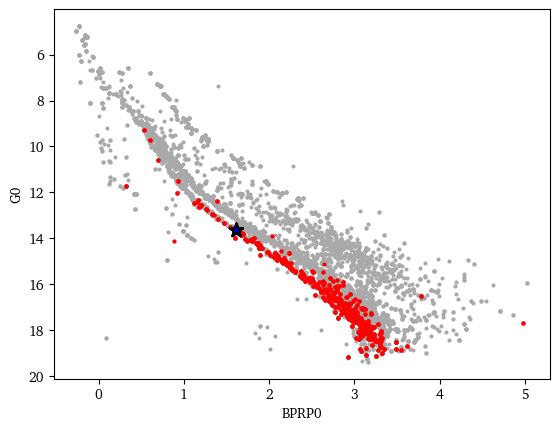

In [237]:
mask_x = (embedding[:, 0] < 0)
mask_y = (embedding[:, 1] < -2)
matching_indices = np.where(mask_x & mask_y)
matching_gids = gaia_ids[matching_indices]
random_index = np.random.choice(matching_indices[0])
random_gid = gaia_ids[random_index]
random_gid_1 = '661283199601699328'
random_index_1 = 4447


# Filter stars
df_region = df[df.loc[:, 'GaiaDR3_ID'].isin(matching_gids)]
plt.scatter(df['BPRP0'],df['G0'], s=15, alpha=1,c='darkgray',marker='.')
plt.scatter(df_region['BPRP0'],df_region['G0'], s=15, alpha=1,c='red',marker='.')
plt.scatter(df.loc[df['GaiaDR3_ID'] == random_gid_1, 'BPRP0'], df.loc[df['GaiaDR3_ID'] == random_gid_1, 'G0'],
            s=100, alpha=1, c='blue', marker='*', edgecolor='black', linewidth=1.5, label='Random Star')
plt.gca().invert_yaxis()
plt.xlabel('BPRP0')
plt.ylabel('G0')
plt.show()

#### Top blob

In [206]:
random_gid

'68283421593270400'

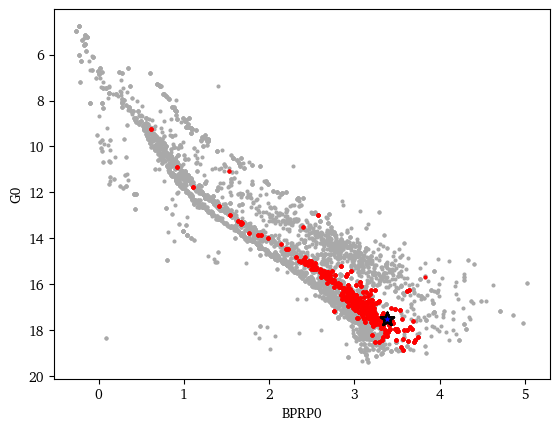

In [207]:
mask_x = (embedding[:, 0] < 4) & (embedding[:, 0] > 2)
mask_y = embedding[:, 1] > 6
matching_indices = np.where(mask_x & mask_y)
matching_gids = gaia_ids[matching_indices]
random_gid = np.random.choice(matching_gids)
random_gid_2 = '68283421593270400'

# Filter stars
df_region = df[df.loc[:, 'GaiaDR3_ID'].isin(matching_gids)]
plt.scatter(df['BPRP0'],df['G0'], s=15, alpha=1,c='darkgray',marker='.')
plt.scatter(df_region['BPRP0'],df_region['G0'], s=15, alpha=1,c='red',marker='.')
plt.scatter(df.loc[df['GaiaDR3_ID'] == random_gid_2, 'BPRP0'], df.loc[df['GaiaDR3_ID'] == random_gid_2, 'G0'],
            s=100, alpha=1, c='blue', marker='*', edgecolor='black', linewidth=1.5, label='Random Star')
plt.gca().invert_yaxis()
plt.xlabel('BPRP0')
plt.ylabel('G0')
plt.show()

#### Right (young)

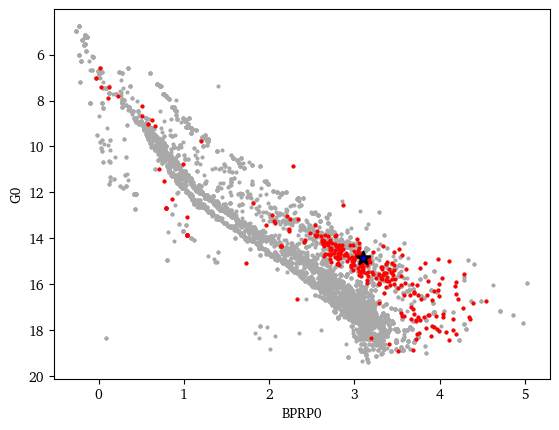

In [196]:
mask_x = (embedding[:, 0] < 8) & (embedding[:, 0] > 7)
mask_y = embedding[:, 1] > 4
matching_indices = np.where(mask_x & mask_y)
matching_gids = gaia_ids[matching_indices]
random_gid = np.random.choice(matching_gids)
random_gid_3 = '6050538893392363136'

# Filter stars
df_region = df[df.loc[:, 'GaiaDR3_ID'].isin(matching_gids)]
plt.scatter(df['BPRP0'],df['G0'], s=15, alpha=1,c='darkgray',marker='.')
plt.scatter(df_region['BPRP0'],df_region['G0'], s=15, alpha=1,c='red',marker='.')
plt.scatter(df.loc[df['GaiaDR3_ID'] == random_gid_3, 'BPRP0'], df.loc[df['GaiaDR3_ID'] == random_gid_3, 'G0'],
            s=100, alpha=1, c='blue', marker='*', edgecolor='black', linewidth=1.5, label='Random Star')
plt.gca().invert_yaxis()
plt.xlabel('BPRP0')
plt.ylabel('G0')
plt.show()

#### Middle

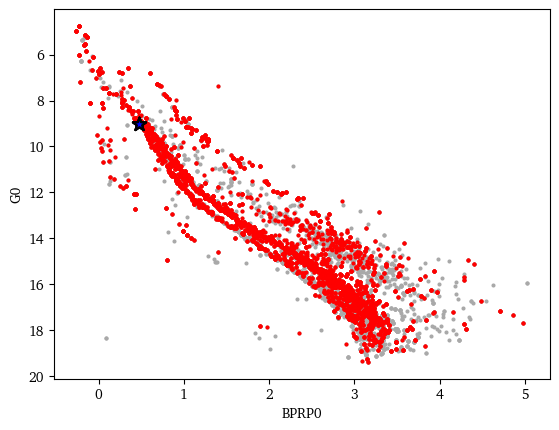

In [215]:
mask_x = (embedding[:, 0] < 10) & (embedding[:, 0] > 2)
mask_y = (embedding[:, 1] > -2) & (embedding[:, 1] < 4)
matching_indices = np.where(mask_x & mask_y)
matching_gids = gaia_ids[matching_indices]
random_gid = np.random.choice(matching_gids)
random_gid_4 = '659466222275521792'

# Filter stars
df_region = df[df.loc[:, 'GaiaDR3_ID'].isin(matching_gids)]
plt.scatter(df['BPRP0'],df['G0'], s=15, alpha=1,c='darkgray',marker='.')
plt.scatter(df_region['BPRP0'],df_region['G0'], s=15, alpha=1,c='red',marker='.')
plt.scatter(df.loc[df['GaiaDR3_ID'] == random_gid_4, 'BPRP0'], df.loc[df['GaiaDR3_ID'] == random_gid_4, 'G0'],
            s=100, alpha=1, c='blue', marker='*', edgecolor='black', linewidth=1.5, label='Random Star')
plt.gca().invert_yaxis()
plt.xlabel('BPRP0')
plt.ylabel('G0')
plt.show()

### Plot latent space

In [430]:
def umap_scatter(c, label, log_scale=False, cmap='viridis_r',
                 bprp0_min=None, bprp0_max=None,
                 point_size=10, alpha=0.5, figsize=(10, 6)):
    """Plot UMAP colored by an arbitrary array, with optional BPRP0 filtering."""
    c = np.asarray(c, dtype=float)
    mask = np.ones(len(embedding), dtype=bool)
    if bprp0_min is not None:
        mask &= (bprp0 >= bprp0_min)
    if bprp0_max is not None:
        mask &= (bprp0 <= bprp0_max)
    mask &= ~np.isnan(c)

    x_p = embedding[mask, 0]
    y_p = embedding[mask, 1]
    c_p = c[mask]

    norm = LogNorm(vmin=c_p.min(), vmax=c_p.max()) if log_scale else Normalize(vmin=c_p.min(), vmax=c_p.max())

    fig, ax = plt.subplots(figsize=figsize)
    sc = ax.scatter(x_p, y_p, c=c_p, cmap=cmap, norm=norm,
                    s=point_size, alpha=alpha, rasterized=True)
    
    # Set colorbar on separate points to have separate alpha
    sm = cm.ScalarMappable(norm=norm, cmap=cmap)
    # sm.set_array([])

    cbar = fig.colorbar(sm, ax=ax, shrink=0.8)
    cbar.set_label(label, fontsize=18)
    cbar.ax.tick_params(labelsize=14)
    ax.set_xlabel('UMAP 1', fontsize=14)
    ax.set_ylabel('UMAP 2', fontsize=14)
    ax.set_xticks([]); ax.set_yticks([])

    info_lines = [f'N = {mask.sum()}']
    if bprp0_min is not None or bprp0_max is not None:
        info_lines.append(f'BPRP0: {bprp0_min or ""}–{bprp0_max or ""}')
    # ax.text(0.02, 0.98, '\n'.join(info_lines), transform=ax.transAxes, fontsize=11,
    #         va='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

    plt.tight_layout()
    return fig, ax

### Stellar age

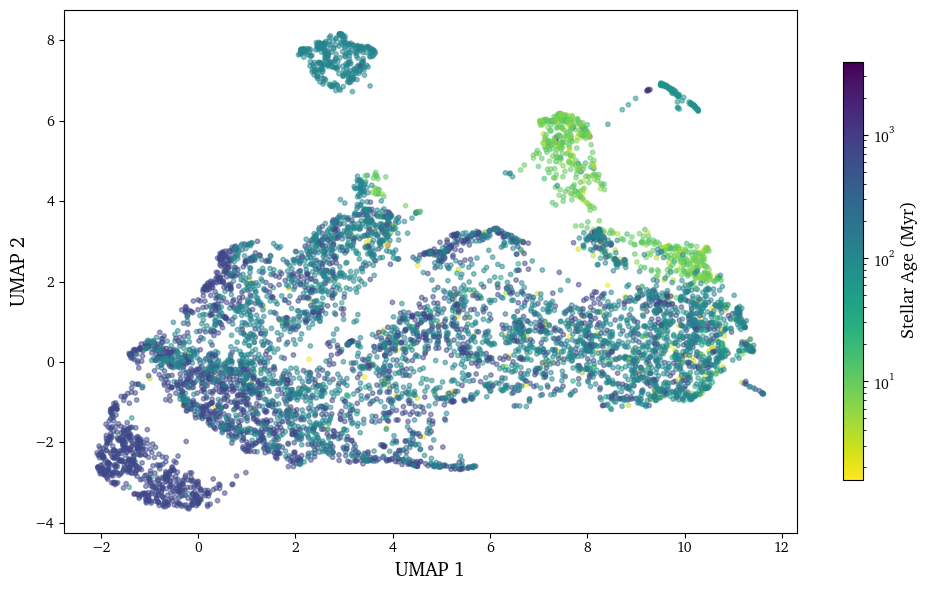

In [158]:
fig, ax = umap_scatter(ages, ' Stellar Age (Myr)', log_scale=True)
# ax.set_title('UMAP – Stellar Age')


plt.show()

### Age with BPRP0 filter to restrict the plotted points to a colour range.

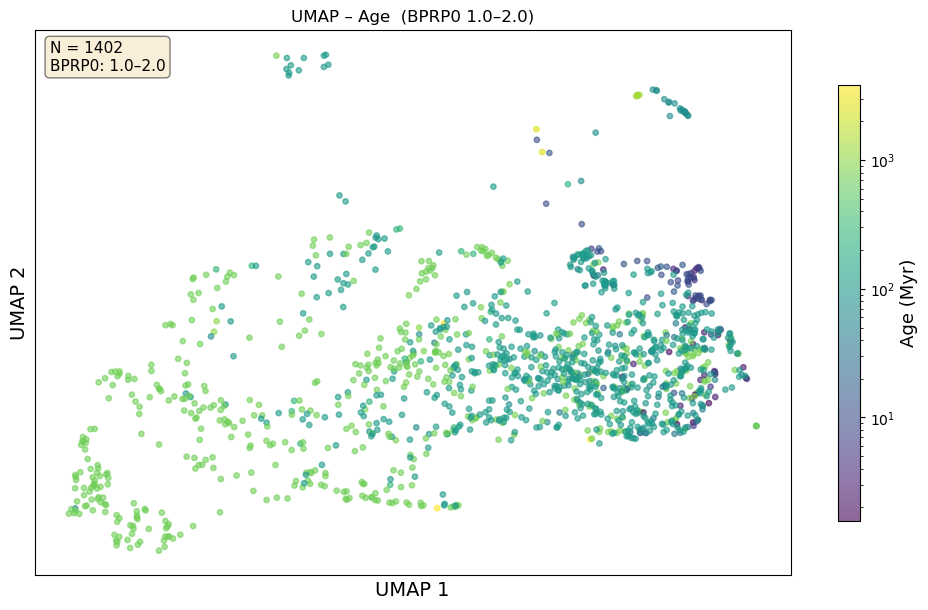

In [10]:
fig, ax = umap_scatter(ages, 'Age (Myr)', log_scale=True,
                       bprp0_min=1.0, bprp0_max=2.0)
ax.set_title('UMAP – Age  (BPRP0 1.0–2.0)')
plt.show()

### BPRP0 color

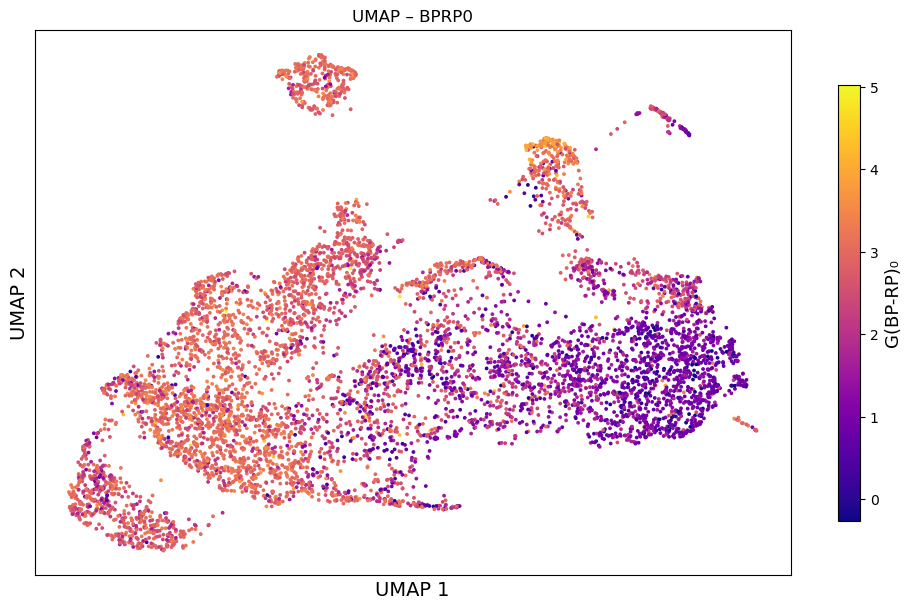

In [23]:
fig, ax = umap_scatter(bprp0, 'G(BP-RP)₀', log_scale=False, cmap='plasma')
ax.set_title('UMAP – BPRP0')
plt.show()

### Color by any phot_all.csv column `Prot`, `parallax`, `G0`, `BP0`, `RP0`, `teff_gspphot`, etc.

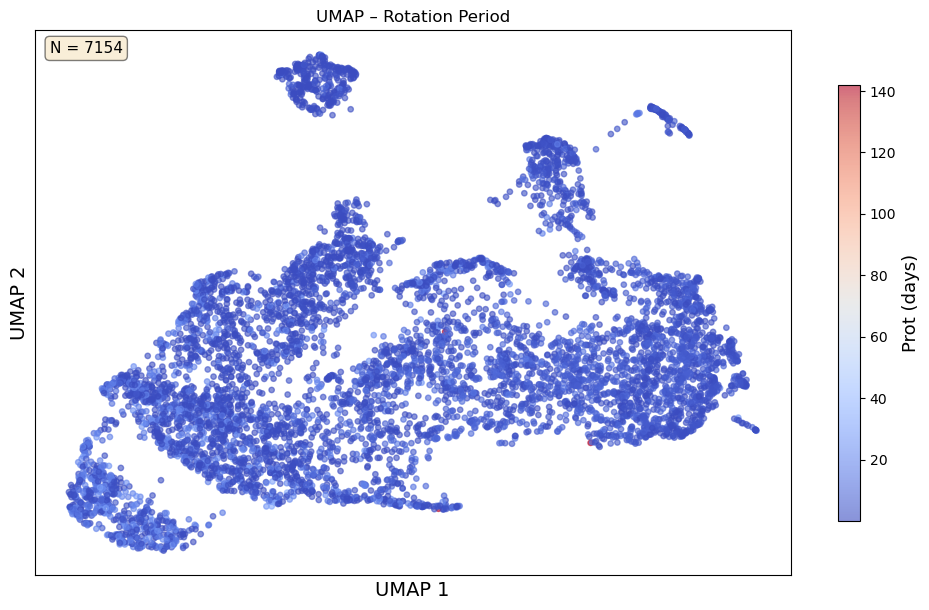

In [12]:
# Example: rotation period
fig, ax = umap_scatter(df['Prot'].values, 'Prot (days)', log_scale=False, cmap='coolwarm')
ax.set_title('UMAP – Rotation Period')
plt.show()

## Find CMD examples

In [134]:
# Blue, bright, 97 Myr
dr3id_1 = '64933759417769984'

# Red, maybe PMS, 760 Myr
dr3id_2 = '145668974102570624'

# Red 718 Myr
dr3id_3 = '658156527832150400'

In [216]:
df_1 = df.loc[(df['GaiaDR3_ID'] == random_gid_1)]
BPRP0_1 = df_1['BPRP0'].values[0]
G0_1 = df_1['G0'].values[0]

df_2 = df.loc[(df['GaiaDR3_ID'] == random_gid_2)]
BPRP0_2 = df_2['BPRP0'].values[0]
G0_2 = df_2['G0'].values[0]

df_3 = df.loc[(df['GaiaDR3_ID'] == random_gid_3)]
BPRP0_3 = df_3['BPRP0'].values[0]
G0_3 = df_3['G0'].values[0]

df_4 = df.loc[(df['GaiaDR3_ID'] == random_gid_4)]
BPRP0_4 = df_4['BPRP0'].values[0]
G0_4 = df_4['G0'].values[0]

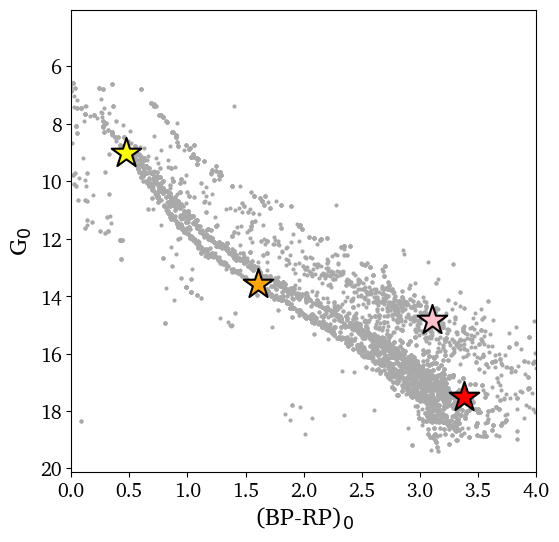

In [327]:
plt.figure(figsize=(6, 6))
plt.scatter(df['BPRP0'],df['G0'], s=15, alpha=1,c='darkgray',marker='.')

plt.scatter(BPRP0_1, G0_1, s=500, alpha=1, c='orange',marker='*', edgecolor='black', linewidth=1.5)
plt.scatter(BPRP0_2, G0_2, s=500, alpha=1, c='red', marker='*', edgecolor='black', linewidth=1.5)
plt.scatter(BPRP0_3, G0_3, s=500, alpha=1, c='pink', marker='*', edgecolor='black', linewidth=1.5)
plt.scatter(BPRP0_4, G0_4, s=500, alpha=1, c='yellow', marker='*', edgecolor='black', linewidth=1.5)

plt.gca().invert_yaxis()
plt.xlim(0,4)
plt.xlabel(r'(BP-RP)$_0$',fontsize=18)
plt.ylabel(r'G$_0$',fontsize=18)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)

plt.show()

### Plot UMAP with specific points

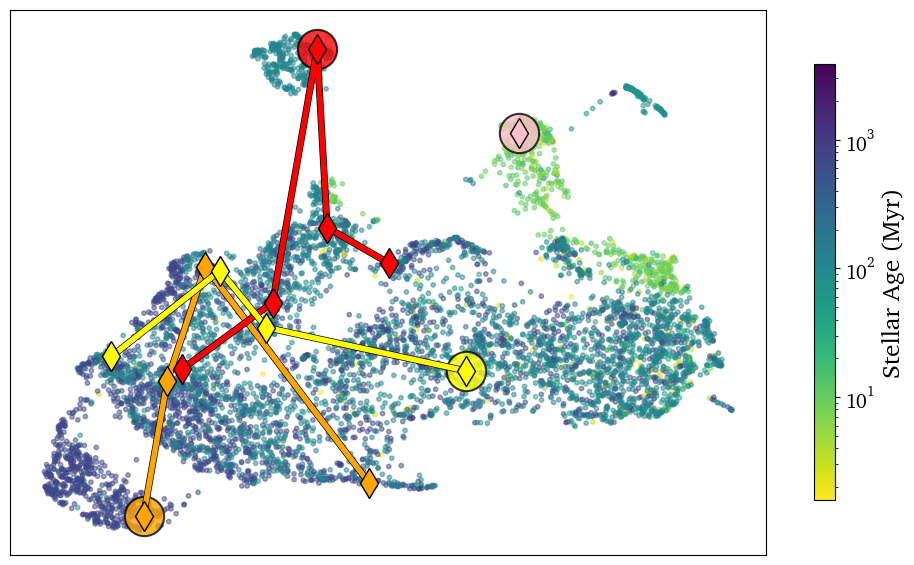

In [476]:
fig, ax = umap_scatter(ages, 'Stellar Age (Myr)', log_scale=True)
# ax.set_title('UMAP – Stellar Age')
umap_ind_1 = np.where(gaia_ids == random_gid_1)[0]
umap_ind_2 = np.where(gaia_ids == random_gid_2)[0]
umap_ind_3 = np.where(gaia_ids == random_gid_3)[0]
umap_ind_4 = np.where(gaia_ids == random_gid_4)[0]

umap_1 = embedding[umap_ind_1]
umap_1_sorted = umap_1[umap_1[:, 0].argsort()]
plt.scatter(umap_1_sorted[0,0], umap_1_sorted[0,1], s=800, alpha=0.8,
            color='orange', marker='o',edgecolor='black', linewidth=1.5)
plt.plot(umap_1_sorted[:,0], umap_1_sorted[:,1], color='black', linewidth=5)
plt.plot(umap_1_sorted[:,0], umap_1_sorted[:,1], markersize=15, alpha=1,
            linestyle='-', color='orange', marker='d',
            markeredgecolor='black',linewidth=4)

umap_2 = embedding[umap_ind_2]
umap_2_sorted = umap_2[umap_2[:, 0].argsort()]
plt.scatter(umap_2_sorted[2,0], umap_2_sorted[2,1], s=800, alpha=0.8,
            color='red', marker='o',edgecolor='black', linewidth=1.5)
plt.plot(umap_2_sorted[:,0], umap_2_sorted[:,1], color='black', linewidth=5)
plt.plot(umap_2_sorted[:,0], umap_2_sorted[:,1], markersize=15, alpha=1,
            linestyle='-', color='red', marker='d',
            markeredgecolor='black',linewidth=4)

umap_3 = embedding[umap_ind_3]
umap_3_sorted = umap_3[umap_3[:, 0].argsort()]
plt.scatter(umap_3_sorted[0,0], umap_3_sorted[0,1], s=800, alpha=0.8,
            color='pink', marker='o',edgecolor='black', linewidth=1.5)
plt.plot(umap_3_sorted[:,0], umap_3_sorted[:,1], color='black', linewidth=5)
plt.plot(umap_3_sorted[:,0], umap_3_sorted[:,1], markersize=15, alpha=1,
            linestyle='-', color='pink', marker='d',
            markeredgecolor='black',linewidth=4)

umap_4 = embedding[umap_ind_4]
umap_4_sorted = umap_4[umap_4[:, 0].argsort()]
plt.scatter(umap_4_sorted[3,0], umap_4_sorted[3,1], s=800, alpha=0.8,
            color='yellow', marker='o',edgecolor='black', linewidth=1.5)
plt.plot(umap_4_sorted[:,0], umap_4_sorted[:,1], color='black', linewidth=5)
plt.plot(umap_4_sorted[:,0], umap_4_sorted[:,1], markersize=15, alpha=1,
            linestyle='-', color='yellow', marker='d',
            markeredgecolor='black',linewidth=4)

ax.set_xlabel('', fontsize=18)
ax.set_ylabel('', fontsize=18)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)

plt.show()

## Get Example Light Curves

In [314]:
# Choose which points to use

umap_1_ref = umap_ind_1[1]      # left most orange point
umap_2_ref = umap_ind_2[0]      # top red point
umap_3_ref = umap_ind_3[0]      # pink point
umap_4_ref = umap_ind_4[0]      # right most yellow point

In [315]:
tic_1 = tic_ids[umap_1_ref]
sector_1 = sectors[umap_1_ref]
tic_2 = tic_ids[umap_2_ref]
sector_2 = sectors[umap_2_ref]
tic_3 = tic_ids[umap_3_ref]
sector_3 = sectors[umap_3_ref]
tic_4 = tic_ids[umap_4_ref]
sector_4 = sectors[umap_4_ref]

In [376]:
res_1 = lk.search_lightcurve(f"TIC {tic_1}", mission='TESS', author=['SPOC'],sector=sector_1,exptime=120)
lc_1 = res_1[0].download()
res_2 = lk.search_lightcurve(f"TIC {tic_2}", mission='TESS', author=['SPOC'],sector=sector_2,exptime=120)
lc_2 = res_2[0].download()
res_3 = lk.search_lightcurve(f"TIC {tic_3}", mission='TESS', author=['SPOC'],sector=sector_3,exptime=120)
lc_3 = res_3[0].download()
res_4 = lk.search_lightcurve(f"TIC {tic_4}", mission='TESS', author=['SPOC'],sector=sector_4,exptime=120)
lc_4 = res_4[0].download()

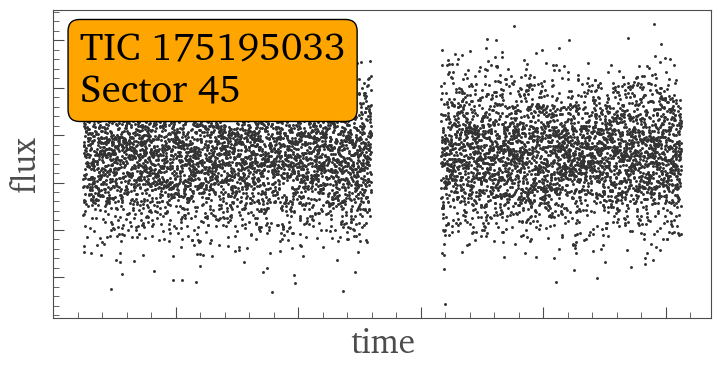

In [456]:
lc_thinned = lc_1[::2]
lc_thinned.scatter(s=5,label='',marker='.')
plt.text(0.04,0.93,f'TIC {tic_1}\nSector {sector_1}',fontsize=28,
         bbox=dict(boxstyle='round', facecolor='orange', alpha=1),ha='left',va='top',
         transform=plt.gca().transAxes)
xl = plt.gca().get_xlabel()
yl = plt.gca().get_ylabel()
plt.gca().set_xlabel('time',fontsize=24)
plt.gca().set_ylabel('flux',fontsize=24)
xtl = plt.gca().get_xticklabels()
ytl = plt.gca().get_yticklabels()
plt.gca().set_xticklabels([],fontsize=18)
plt.gca().set_yticklabels([],fontsize=18)
plt.show()

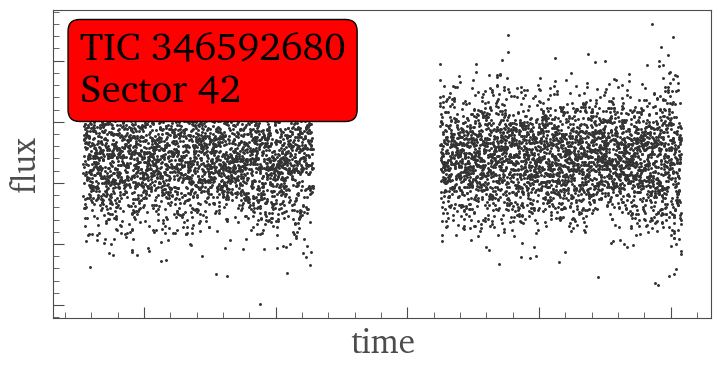

In [457]:
lc_thinned = lc_2[::2]
lc_thinned.scatter(s=5,label='',marker='.')
plt.text(0.04,0.93,f'TIC {tic_2}\nSector {sector_2}',fontsize=28,
         bbox=dict(boxstyle='round', facecolor='red', alpha=1),ha='left',va='top',
         transform=plt.gca().transAxes)
xl = plt.gca().get_xlabel()
yl = plt.gca().get_ylabel()
plt.gca().set_xlabel('time',fontsize=24)
plt.gca().set_ylabel('flux',fontsize=24)
xtl = plt.gca().get_xticklabels()
ytl = plt.gca().get_yticklabels()
plt.gca().set_xticklabels([],fontsize=18)
plt.gca().set_yticklabels([],fontsize=18)
plt.show()

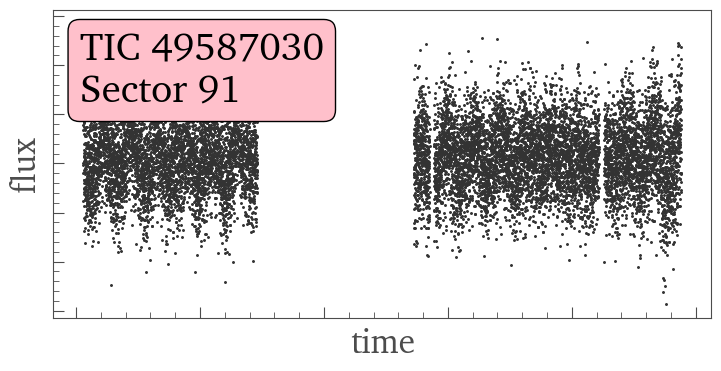

In [458]:
lc_thinned = lc_3[::1]
lc_thinned.scatter(s=5,label='',marker='.')
plt.text(0.04,0.93,f'TIC {tic_3}\nSector {sector_3}',fontsize=28,
         bbox=dict(boxstyle='round', facecolor='pink', alpha=1),ha='left',va='top',
         transform=plt.gca().transAxes)
xl = plt.gca().get_xlabel()
yl = plt.gca().get_ylabel()
plt.gca().set_xlabel('time',fontsize=24)
plt.gca().set_ylabel('flux',fontsize=24)
xtl = plt.gca().get_xticklabels()
ytl = plt.gca().get_yticklabels()
plt.gca().set_xticklabels([],fontsize=18)
plt.gca().set_yticklabels([],fontsize=18)
plt.show()

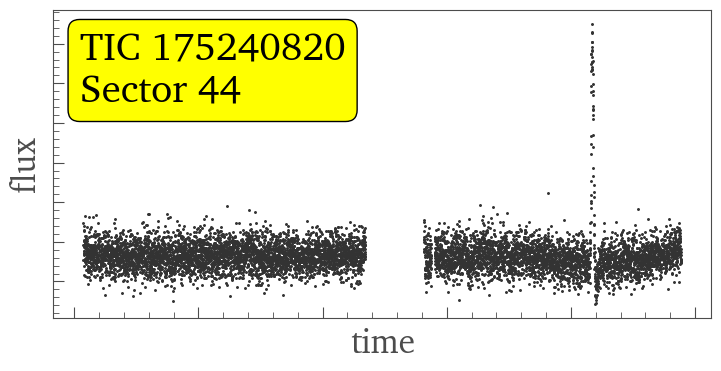

In [461]:
lc_thinned = lc_4[::2]
lc_thinned.scatter(s=5,label='',marker='.')
plt.text(0.04,0.93,f'TIC {tic_4}\nSector {sector_4}',fontsize=28,
         bbox=dict(boxstyle='round', facecolor='yellow', alpha=1),ha='left',va='top',
         transform=plt.gca().transAxes)
xl = plt.gca().get_xlabel()
yl = plt.gca().get_ylabel()
plt.gca().set_xlabel('time',fontsize=24)
plt.gca().set_ylabel('flux',fontsize=24)
xtl = plt.gca().get_xticklabels()
ytl = plt.gca().get_yticklabels()
plt.gca().set_xticklabels([],fontsize=18)
plt.gca().set_yticklabels([],fontsize=18)
plt.show()

In [330]:
res

#,mission,year,author,exptime,target_name,distance
,,,,s,,arcsec
0,TESS Sector 45,2021,SPOC,120,175195033,0.0
